In [28]:
## Stage 1: Extract & Load

# We fetch daily weather data from the Open-Meteo API and load it into the raw table.  
# One run = one logical date. Re-running must not duplicate rows.
import subprocess

# Run extract_load.py for one logical date
subprocess.run(["python", "/opt/airflow/ingestion/extract_load.py", "2026-09-01"])


✅ Data loaded into Postgres for 2026-09-01 → 2026-09-01!


CompletedProcess(args=['python', '/opt/airflow/ingestion/extract_load.py', '2026-09-01'], returncode=0)

In [29]:
## Stage 2: Transform (dbt)

# In the DAG, dbt runs inside the Airflow container (`dbt run` + `dbt test`).  
# Here in the notebook, we query the staging and mart tables that dbt has already materialized.  
# This demonstrates the transformations and lets us validate the outputs.
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    dbname="warehouse",
    user="de",
    password="de",
    host="postgres",
    port="5432"
)

stg_sample = pd.read_sql("SELECT * FROM stg_weather LIMIT 5;", conn)
mart_sample = pd.read_sql("""
SELECT weather_date, city, avg_temp, max_temp, min_temp, total_rain, rain_category
FROM mart_weather
ORDER BY weather_date DESC
LIMIT 5;
""", conn)

display(stg_sample)
display(mart_sample)

conn.close()


/tmp/ipykernel_26162/1119552315.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  stg_sample = pd.read_sql("SELECT * FROM stg_weather LIMIT 5;", conn)
/tmp/ipykernel_26162/1119552315.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  mart_sample = pd.read_sql("""


,city,weather_date,temperature,precipitation
0,Bangalore,2026-09-12,30.799999,0.4
1,Bangalore,2026-08-12,28.700001,0.6
2,Bangalore,2026-08-13,28.900000,5.6
3,Bangalore,2026-08-14,29.500000,5.3
4,Bangalore,2026-08-15,29.299999,1.1


,weather_date,city,avg_temp,max_temp,min_temp,total_rain,rain_category
0,2026-09-12,Bangalore,30.799999,30.799999,30.799999,0.4,Light/No Rain
1,2026-09-11,Bangalore,31.000000,31.000000,31.000000,0.7,Light/No Rain
2,2026-09-10,Bangalore,30.100000,30.100000,30.100000,1.0,Light/No Rain
3,2026-09-09,Bangalore,30.600000,30.600000,30.600000,5.1,Light/No Rain
4,2026-09-08,Bangalore,31.000000,31.000000,31.000000,1.6,Light/No Rain


In [30]:
## Stage 3: Orchestration

# Airflow orchestrates the pipeline with tasks:
# - `extract_weather` → runs ingestion script for one logical date
# - `extract_weather_range` → supports backfills with start/end dates
# - `dbt_run` → runs dbt models
# - `dbt_test` → validates dbt outputs

# The DAG definition shows how these tasks are chained together.
# Just read the DAG file to show orchestration logic
with open("/opt/airflow/dags/weather_pipeline.py") as f:
    dag_code = f.read()

print(dag_code[:])  # print first 500 chars for preview



from airflow import DAG
from airflow.operators.bash import BashOperator
from airflow.models import Variable
from datetime import datetime

default_args = {
    "owner": "airflow",
    "retries": 1,
}

with DAG(
    dag_id="weather_pipeline",
    start_date=datetime(2026, 8, 1),
    schedule_interval="@daily",   # runs once per day
    catchup=True,
    default_args=default_args,
) as dag:

    # Daily run: Airflow injects {{ ds }} (execution date)
    extract = BashOperator(
        task_id="extract_weather",
        bash_command="python /opt/airflow/ingestion/extract_load.py {{ ds }}"
    )

    # Optional backfill run: use conf to pass start_date and end_date
    # Example trigger:
    # airflow dags trigger weather_pipeline --conf '{"start_date":"2026-09-01","end_date":"2026-09-10"}'
    extract_range = BashOperator(
        task_id="extract_weather_range",
        bash_command=(
            "python /opt/airflow/ingestion/extract_load.py "
            "{{ dag_run.conf.get('start_dat

In [31]:
## Stage 4: Re-run Safety

# We load the same date twice and show that row counts are unchanged.  
# This proves the pipeline is idempotent — re-runs don’t duplicate rows.
import psycopg2
import pandas as pd
import subprocess

conn = psycopg2.connect(
    dbname="warehouse",
    user="de",
    password="de",
    host="postgres",
    port="5432"
)

before = pd.read_sql("SELECT COUNT(*) FROM raw_weather;", conn)

# Re-run same date
subprocess.run(["python", "/opt/airflow/ingestion/extract_load.py", "2026-09-01"])

after = pd.read_sql("SELECT COUNT(*) FROM raw_weather;", conn)

display(before)
display(after)

conn.close()


/tmp/ipykernel_26162/2312914229.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  before = pd.read_sql("SELECT COUNT(*) FROM raw_weather;", conn)


✅ Data loaded into Postgres for 2026-09-01 → 2026-09-01!


/tmp/ipykernel_26162/2312914229.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  after = pd.read_sql("SELECT COUNT(*) FROM raw_weather;", conn)


,count
0,32


,count
0,32


In [32]:
## Stage 5: Business Metrics

# We query the mart to show results a business user would recognise.
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    dbname="warehouse",
    user="de",
    password="de",
    host="postgres",
    port="5432"
)

mart_business = pd.read_sql("""
SELECT city, weather_date, avg_temp, rain_category
FROM mart_weather
ORDER BY weather_date DESC
LIMIT 10;
""", conn)

display(mart_business)

conn.close()


/tmp/ipykernel_26162/2226257569.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  mart_business = pd.read_sql("""


,city,weather_date,avg_temp,rain_category
0,Bangalore,2026-09-12,30.799999,Light/No Rain
1,Bangalore,2026-09-11,31.000000,Light/No Rain
2,Bangalore,2026-09-10,30.100000,Light/No Rain
3,Bangalore,2026-09-09,30.600000,Light/No Rain
4,Bangalore,2026-09-08,31.000000,Light/No Rain
5,Bangalore,2026-09-07,30.900000,Light/No Rain
6,Bangalore,2026-09-06,30.500000,Light/No Rain
7,Bangalore,2026-09-05,30.799999,Light/No Rain
8,Bangalore,2026-09-04,29.299999,Light/No Rain
9,Bangalore,2026-09-03,28.700001,Light/No Rain


/tmp/ipykernel_26162/3902673839.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  trend_df = pd.read_sql("""


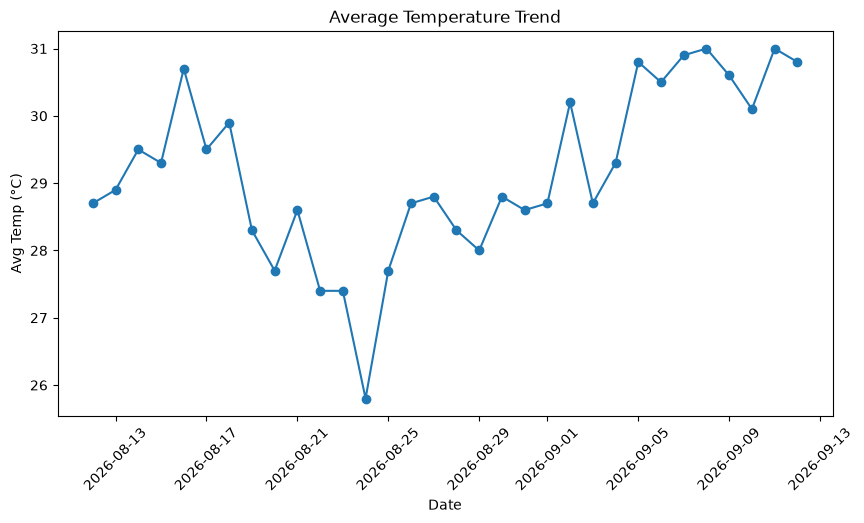

In [33]:
## Stage 6: Visualization

# We plot a simple trend of average temperature over time.
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    dbname="warehouse",
    user="de",
    password="de",
    host="postgres",
    port="5432"
)

trend_df = pd.read_sql("""
SELECT weather_date, avg_temp
FROM mart_weather
ORDER BY weather_date;
""", conn)

conn.close()

plt.figure(figsize=(10,5))
plt.plot(trend_df['weather_date'], trend_df['avg_temp'], marker='o')
plt.title("Average Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Avg Temp (°C)")
plt.xticks(rotation=45)
plt.show()

